# <font color='violet'>TABLE OF CONTENTS<font><a class='anchor' id='top'></a>
- [Introduction to the Bellabeat data analysis case study](#1)
- [Overview of the available data](#2)
- [Data import and transformation](#3)
- [Data import and transformation](##3)
    
# <ins><font color='violet'>Introduction to the Bellabeat data analysis case study<font><a class='anchor' id='top'></a><ins>

In this scenario, we play the role of a junior data analyst working in the marketing department of Bellabeat company. Our main task is to help the company find new opportunities for growth. For this, we can explore and analyze the **Fitbit crowdsourced dataset** to draw some conclusions regarding the trends in the usage of fitness tracker devices. 

---
## Analysis roadmap

The general data analysis process is represented by a Case Study Roadmap, which includes steps such as:

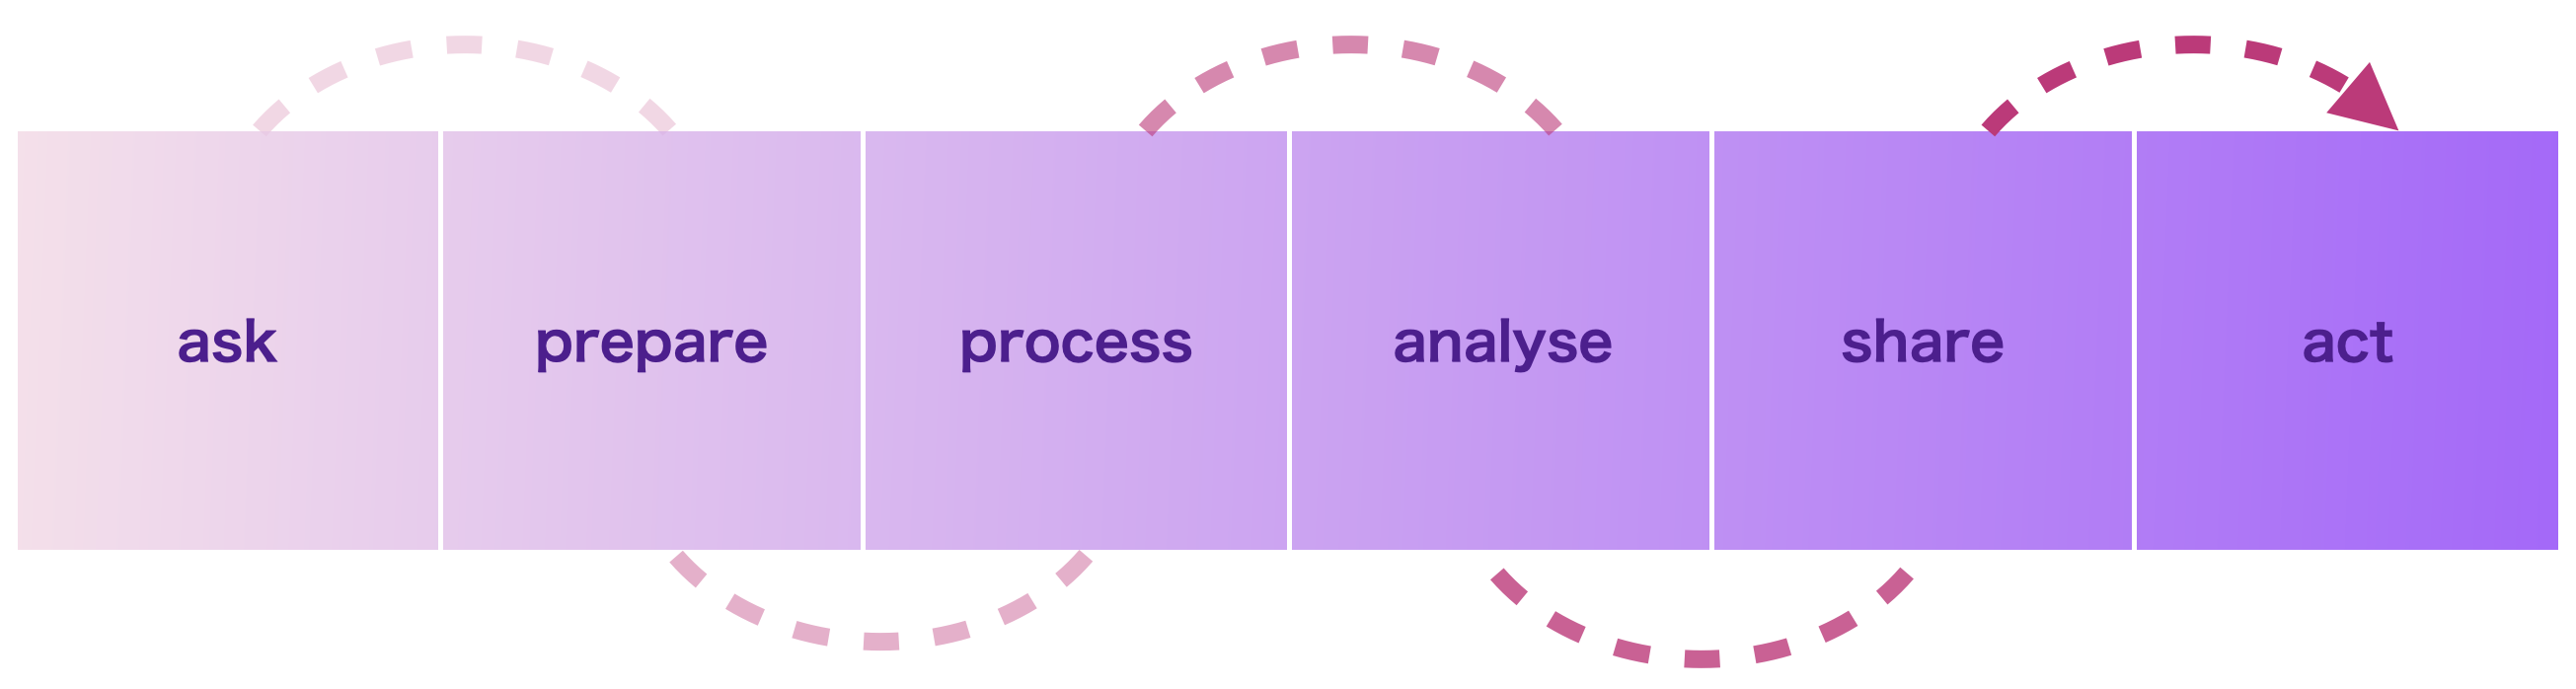
---
## Ask

The main goal of the data analysis is to get insightes into how people use smart devices, namely:
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?

--- 
## Prepare
- FitBit Fitness Tracker Data is a second-party data
- The data is structured (organised in comma separated values sheets)
- Thirty-five people initially participated in the data collection (however, after excluding two IDs with only a few entries, we are left with data from thirty-three people)

A larger sample size would enhance representatives, making the data more statistically reliable. We need to be cautious regarding bias and strive for fairness. It's possible that the population is underrepresented, leading to skewed results and reduced accuracy

Location:
- https://zenodo.org/records/53894#.X9oeh3Uzaao **[HAS THE DATA FOR 3.12.16-4.11.16 and 4.12.16- 5.12.16 in TWO separate folders!]**
- https://www.kaggle.com/datasets/arashnic/fitbit/data **[HAS THE DATA FROM 4.12.16 to 5.12.16 ONLY!]**

Documentation:
    - https://www.fitabase.com/media/1930/fitabasedatadictionary102320.pdf

---
**How the data will help us to find answers to the stakeholders questions**: 

--- 
## Data import and transformation
Before handling the data and drawing conclusions, the data should be prepared for the analysis. The preparation stage includes data transformation. 

Data transformation usually involves:

- Adding, copying, or replicating data 
- Deleting fields or records 
- Standardizing the names of variables
- Renaming, moving, or combining columns in a database
- Joining one set of data with another
- Saving a file in a different format. For example, saving a spreadsheet as a comma separated values (CSV) file.
---



# <ins><font color='violet'> Overview of the available data<font><a class='anchor' id='top'></a><ins>


First of all, let's upload all the packages we will need for the data analysis and evaluate the available records

In [2]:
#install.packages("tidyverse") # The set of packages for data wrangling
library(tidyverse)
#install.packages("ggsci") # The set of packages for 
library( ggsci)
#install.packages("ggthemes") # The package provides a set of useful themes for plots
library(ggthemes)
#install.packages("viridisLite") # The package provides color themes
library(viridisLite)
#install.packages("RColorBrewer") # The package provides color themes
library(RColorBrewer)
#install.packages("rmarkdown") # for creating the document (in a variety of formats) that combines code, rendered output (such as figures), and prose 
library(rmarkdown)
#install.packages("knitr")
library(knitr)
#install.packages("kableExtra") # kableExtra helps to build common complex tables
library(kableExtra)
library(lubridate)
#install.packages("gridExtra") # Install gridExtra package
library(gridExtra)
#install.packages("sqldf")
library(sqldf)
#install.packages("proto")
library(proto)
#install.packages("gsubfn")
library(gsubfn)
#install.packages("RSQLite") # Embeds the SQLite database engine in R 
library(RSQLite)
#install.packages("dbplyr")
library(dbplyr)
#install.packages("reshape2")
library(reshape2)
library(repr) # String and binary representations of objects for several formats / mime types
library(patchwork)
#install.packages("plotly") # is an R package for creating interactive web-based graphs
library(ggplot2)
library(plotly) 
library(ggsignif)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




First of all, let's upload the datasets from https://zenodo.org/records/53894#.X9oeh3Uzaao into the R environment and merge them together to see if we have all the data for the entire survey period from 03.12.2016 to 05.12.2016. We can take a look at the overall daily activity records by merging the two separate daily_activity.csv files for the two different time periods.


In [3]:
daily_activity_march_april <- read_csv("/kaggle/input/fitabase-data-3-12-16-4-11-2-16/Fitabase Data 3.12.16-4.11-2.16/dailyActivity_merged.csv", show_col_types = FALSE)
daily_activity_april_may <- read_csv("/kaggle/input/fitabase-data-4-12-16-5-12-16-2/Fitabase Data 4.12.16-5.12-2.16/dailyActivity_merged.csv", show_col_types = FALSE)
daily_activity_merged <- rbind(daily_activity_march_april, daily_activity_april_may) # merge two data sets into one
str(daily_activity_merged) # we can see that ActivityDate has a chr type, which should be changed to Date

daily_activity_merged <- daily_activity_merged %>% 
    mutate(ActivityDate = as.Date(ActivityDate, "%m/%d/%Y")) # we change the format of ActivityDate

spc_tbl_ [1,397 × 15] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Id                      : num [1:1397] 1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ ActivityDate            : chr [1:1397] "3/25/2016" "3/26/2016" "3/27/2016" "3/28/2016" ...
 $ TotalSteps              : num [1:1397] 11004 17609 12736 13231 12041 ...
 $ TotalDistance           : num [1:1397] 7.11 11.55 8.53 8.93 7.85 ...
 $ TrackerDistance         : num [1:1397] 7.11 11.55 8.53 8.93 7.85 ...
 $ LoggedActivitiesDistance: num [1:1397] 0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveDistance      : num [1:1397] 2.57 6.92 4.66 3.19 2.16 ...
 $ ModeratelyActiveDistance: num [1:1397] 0.46 0.73 0.16 0.79 1.09 ...
 $ LightActiveDistance     : num [1:1397] 4.07 3.91 3.71 4.95 4.61 ...
 $ SedentaryActiveDistance : num [1:1397] 0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveMinutes       : num [1:1397] 33 89 56 39 28 30 33 47 40 15 ...
 $ FairlyActiveMinutes     : num [1:1397] 12 17 5 20 28 13 12 21 11 30 ...
 $ LightlyActiveMinutes    : num [1:1397] 

We can check what period the merged data set covers and how many pople submitted their data


In [4]:
daily_activity_merged %>%
    summarize(number_of_participants = n_distinct(Id),
             from = min(ActivityDate),
             to = max(ActivityDate))

number_of_participants,from,to
<int>,<date>,<date>
35,2016-03-12,2016-05-12




<div class="alert alert-success">
<b></b> <b>35</b> people submitted their data from <b>12th of March to 12th of May</b>.
</div>

We can check if we have some missing records in the daily_activity dataset. For that, we can use the **geom_tile()** function to plot a heatmap and show if we have days with no information about daily activities logged in

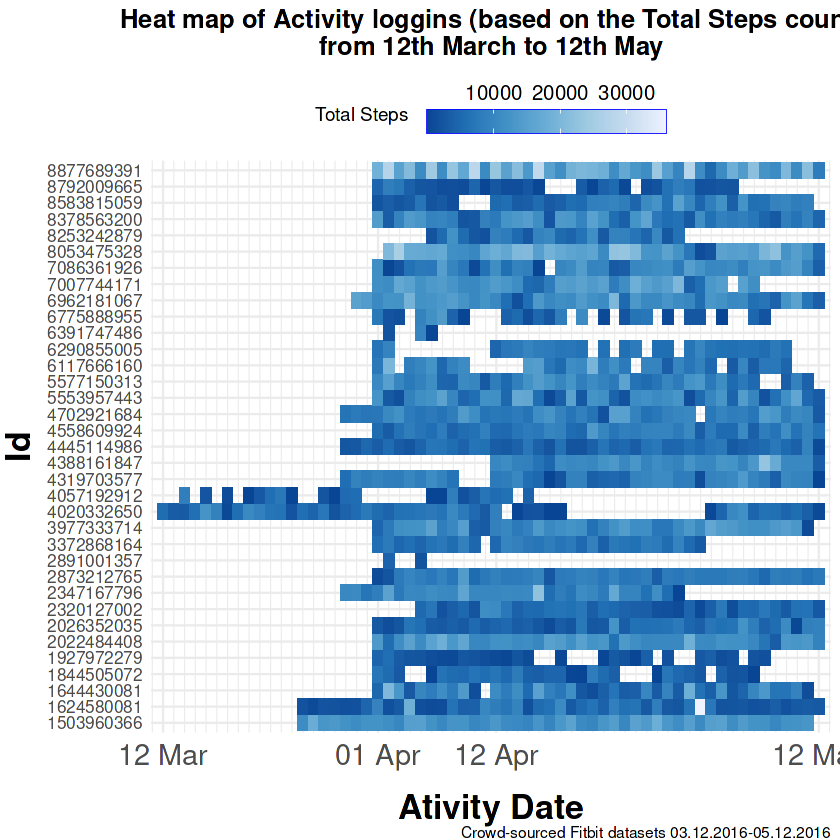

In [5]:
merged_daily_activity <- ggplot(data = daily_activity_merged %>% filter(TotalSteps >0), mapping = aes(x = ActivityDate, 
                                         y = as.character(Id), 
                                         fill = TotalSteps)) + # We do not account for entries with zero TotalSteps here
  geom_tile() +
labs(x = "Ativity Date",
     y = "Id",
     title = "Heat map of Activity loggins (based on the Total Steps count)\nfrom 12th March to 12th May",
     caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
theme_minimal() +
scale_fill_distiller() +
scale_x_date(date_labels = "%d %b", 
             breaks = as.Date(c('2016-03-12','2016-04-1','2016-04-12', '2016-05-12')), 
             date_minor_breaks = "1 day",
             expand = c(0.01,0))+
theme(axis.text.x = element_text(vjust = 0.5, size = 17),
      axis.text.y = element_text(size = 10),
      plot.caption = element_text(vjust = -2, size = 9),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 20, color = "black"),
      axis.title.y = element_text(vjust = 1.5, face = "bold", size = 20, color = "black"),
      legend.position = "top",
      legend.text = element_text(size = 12),
      legend.spacing.x = unit(0.5, 'cm'),
     plot.title = element_text(size = 15, hjust = 0.5, face = "bold")) + 
guides(fill = guide_colorbar(title = "Total Steps",
                               label.position = "top",
                               title.position = "left", title.vjust = 0.3,
                               frame.colour = "blue",
                               barwidth = 10,
                               barheight = 1))

merged_daily_activity

<div class="alert alert-block alert-info">
<b></b> So, as per my understanding, there are missing records for the first month of the survey in the files from https://www.kaggle.com/datasets/arashnic/fitbit/data. While the records from April to May are inconsistent, nonetheless, we can still use the data available starting from the 1st of April (with the exception of 2891001357 and 6391747486), thus adding additional data for the analysis. Obviously, each available dataset has to be checked separately. Perhaps the Sleep or Intensities data have more logins compared to the daily activity data. Further data inspection is shown in <b>Data Import and Transformation<b>.
</div>

# <ins><font color='violet'>Data import and transformation<font><a class='anchor' id='top'></a><ins>

Since we have established that our data can be extended by adding records from April, let's merge the available datasets, transform them, and check for duplicates and NA values.

### Daily Activity


In [6]:
daily_activity <- daily_activity_merged %>%
  arrange(ActivityDate) %>% 
  filter(ActivityDate >= "2016-04-01", Id != 6391747486, Id != 2891001357) #filter out earlier dates and two Id with only several records . We are left with 1,309 rows
str(daily_activity)


nrow(daily_activity[duplicated(daily_activity), ]) #count number of duplicate rows. The result is 0
n_distinct(daily_activity$ActivityDate) # Data collected over a 42-day period
n_distinct(daily_activity$Id) # Data collected for 33 survey participants

tibble [1,309 × 15] (S3: tbl_df/tbl/data.frame)
 $ Id                      : num [1:1309] 1.50e+09 1.62e+09 1.64e+09 1.84e+09 1.93e+09 ...
 $ ActivityDate            : Date[1:1309], format: "2016-04-01" "2016-04-01" ...
 $ TotalSteps              : num [1:1309] 12262 9218 4636 6847 4317 ...
 $ TotalDistance           : num [1:1309] 7.87 5.99 3.41 4.53 2.99 ...
 $ TrackerDistance         : num [1:1309] 7.87 5.99 3.41 4.53 2.99 ...
 $ LoggedActivitiesDistance: num [1:1309] 0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveDistance      : num [1:1309] 3.32 0 0 0.61 0 ...
 $ ModeratelyActiveDistance: num [1:1309] 0.83 0 0.78 0.37 0.37 ...
 $ LightActiveDistance     : num [1:1309] 3.64 5.97 2.6 3.55 2.62 ...
 $ SedentaryActiveDistance : num [1:1309] 0 0.01 0.03 0 0 ...
 $ VeryActiveMinutes       : num [1:1309] 47 0 0 9 0 72 0 0 0 0 ...
 $ FairlyActiveMinutes     : num [1:1309] 21 0 16 9 11 16 0 0 33 0 ...
 $ LightlyActiveMinutes    : num [1:1309] 200 221 586 251 192 213 166 0 212 41 ...
 $ SedentaryMinu

[1] 0

[1] 42

[1] 33

Let's check the data for outliers before proceeding to analysis. We can visualize outliers with a histogram, boxplot, or Q-Q plot.

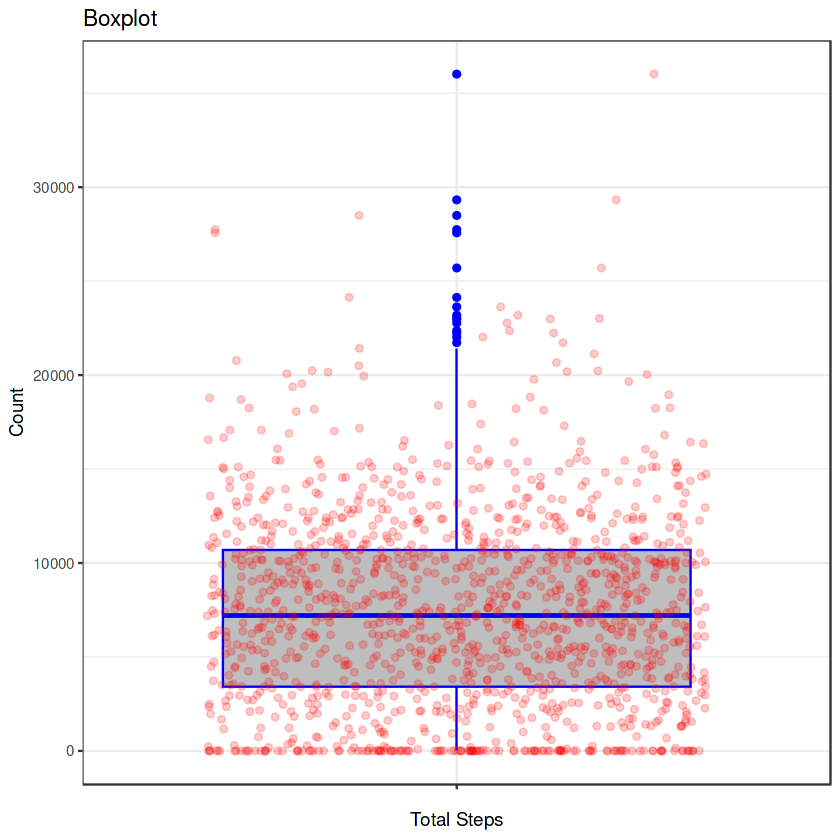

In [7]:
#We can clearly see outliers with geom_boxplot() and geom_jitter() (many red dots are at y = 0). If we don't remove some of them, the final result might be skewed.

total_steps_outliers <- ggplot(daily_activity, aes(x = " ", y = TotalSteps)) +
  geom_boxplot(color = "blue", fill = "gray") +
geom_jitter(alpha = 0.2, color = "red") +
  theme_bw() +
  labs(title = "Boxplot",
       x = "Total Steps",
       y = "Count") 
total_steps_outliers

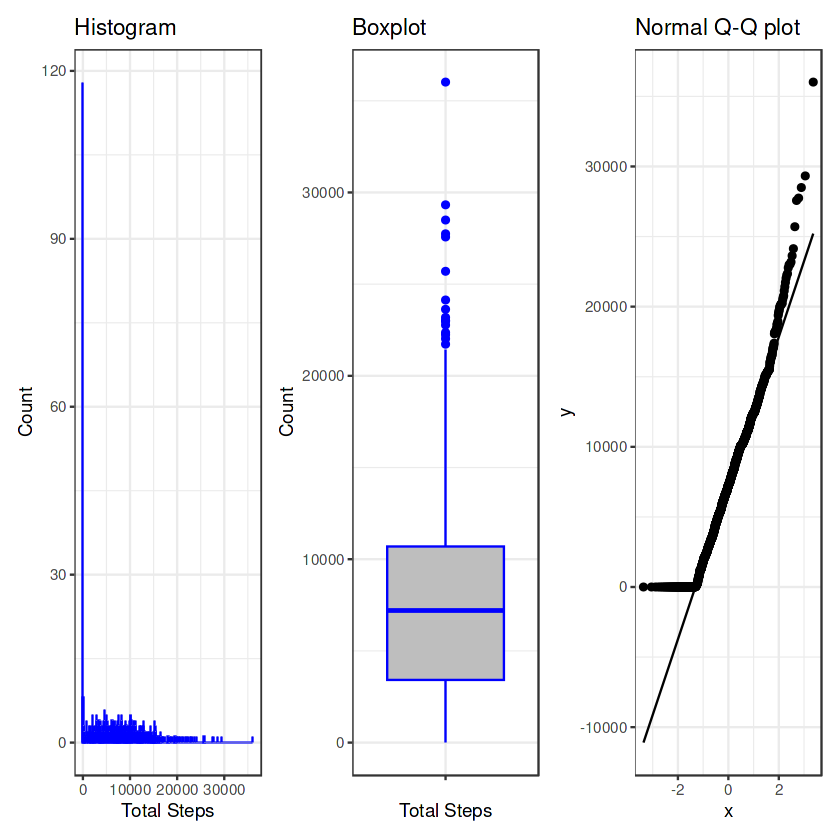

In [8]:
#the comparison of all three methods to visualize outliers 

# Let's visualise the distribution of available sleep data with histogram
plot1 <- ggplot(daily_activity, aes(x = TotalSteps)) +
  geom_histogram(binwidth = 15, color = "blue", fill = "gray") +
  theme_bw() +
  labs(title = "Histogram",
       x = "Total Steps",
       y = "Count")

#we can clearly see outliers with geom_boxplot()
plot2 <- ggplot(daily_activity, aes(x = " ", y = TotalSteps)) +
  geom_boxplot(color = "blue", fill = "gray") +
  theme_bw() +
  labs(title = "Boxplot",
       x = "Total Steps",
       y = "Count") 

#we can also see outliers with Normal Q-Q plot
plot3 <- ggplot(daily_activity, aes(sample = TotalSteps)) + 
    geom_qq() +
    stat_qq_line() +
    theme_bw() +
    labs(title = "Normal Q-Q plot")

(plot1 | plot2 | plot3) # visualise both representations side-by-side with patchwork package

We can use the interquartile range to detect outliers (maybe there are other more suitable methods, this one seems to be working and we just gonna use it here for preliminary analysis)

In [9]:
# we can refer to https://www.geeksforgeeks.org/outlier-analysis-in-r/

# create detect outlier function
detect_outlier <- function(x) {
   
  # calculate first quantile
  Quantile1 <- quantile(x, probs=.25)
   
  # calculate third quantile
  Quantile3 <- quantile(x, probs=.75)
   
  # calculate inter quartile range
  IQR = Quantile3-Quantile1
   
  # return true or false
  x > Quantile3 + (IQR*1.5) | x < Quantile1 - (IQR*1.5)
}
 
# create remove outlier function
remove_outlier <- function(dataframe,
                            columns=names(dataframe)) {
   
  # for loop to traverse in columns vector
  for (col in columns) {
     
    # remove observation if it satisfies outlier function
    dataframe <- dataframe[!detect_outlier(dataframe[[col]]), ]
  }
   
  # return dataframe
  print("Remove outliers")
  print(dataframe)
}

Before removing outliers from daily_activity dataset, we can filter out rows that have zero values. I assume it makes more sense to filter out zero rows (112 records) because we don't know if the data was not recorded simply because the participants didn't wear the watch or because they didn't take any steps.

In [10]:
daily_activity_test_without_zeros <- daily_activity %>% 
  filter(TotalSteps + 
           TotalDistance + 
           TrackerDistance + 
           LoggedActivitiesDistance +
           VeryActiveDistance + 
           ModeratelyActiveDistance + 
           LightActiveDistance + 
           SedentaryActiveDistance + 
           VeryActiveMinutes +
           FairlyActiveMinutes + 
           LightActiveDistance > 0)

daily_activity_new <- remove_outlier(daily_activity_test_without_zeros, c('TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'))


[1] "Remove outliers"
# A tibble: 775 × 15
           Id ActivityDate TotalSteps TotalDistance TrackerDistance
        <dbl> <date>            <dbl>         <dbl>           <dbl>
 1 1503960366 2016-04-01        12262         7.87            7.87 
 2 1844505072 2016-04-01         6847         4.53            4.53 
 3 1927972279 2016-04-01         4317         2.99            2.99 
 4 2026352035 2016-04-01         2605         1.62            1.62 
 5 2347167796 2016-04-01         8328         5.51            5.51 
 6 2873212765 2016-04-01          890         0.600           0.600
 7 3977333714 2016-04-01         4499         3.01            3.01 
 8 4020332650 2016-04-01         5351         3.84            3.84 
 9 4319703577 2016-04-01         9343         6.27            6.27 
10 4445114986 2016-04-01         3271         2.19            2.19 
# ℹ 765 more rows
# ℹ 10 more variables: LoggedActivitiesDistance <dbl>,
#   VeryActiveDistance <dbl>, ModeratelyActiveDistance <dbl>,
#   Li

Let's compare how the boxplots look like for TotalSteps variable before and after outliers were removed.

[1] "Remove outliers"
# A tibble: 770 × 15
           Id ActivityDate TotalSteps TotalDistance TrackerDistance
        <dbl> <date>            <dbl>         <dbl>           <dbl>
 1 1844505072 2016-04-01         6847         4.53            4.53 
 2 1927972279 2016-04-01         4317         2.99            2.99 
 3 2026352035 2016-04-01         2605         1.62            1.62 
 4 2320127002 2016-04-01            0         0               0    
 5 2873212765 2016-04-01          890         0.600           0.600
 6 3977333714 2016-04-01         4499         3.01            3.01 
 7 4020332650 2016-04-01         5351         3.84            3.84 
 8 4057192912 2016-04-01            0         0               0    
 9 4319703577 2016-04-01         9343         6.27            6.27 
10 4388161847 2016-04-01            0         0               0    
# ℹ 760 more rows
# ℹ 10 more variables: LoggedActivitiesDistance <dbl>,
#   VeryActiveDistance <dbl>, ModeratelyActiveDistance <dbl>,
#   Li

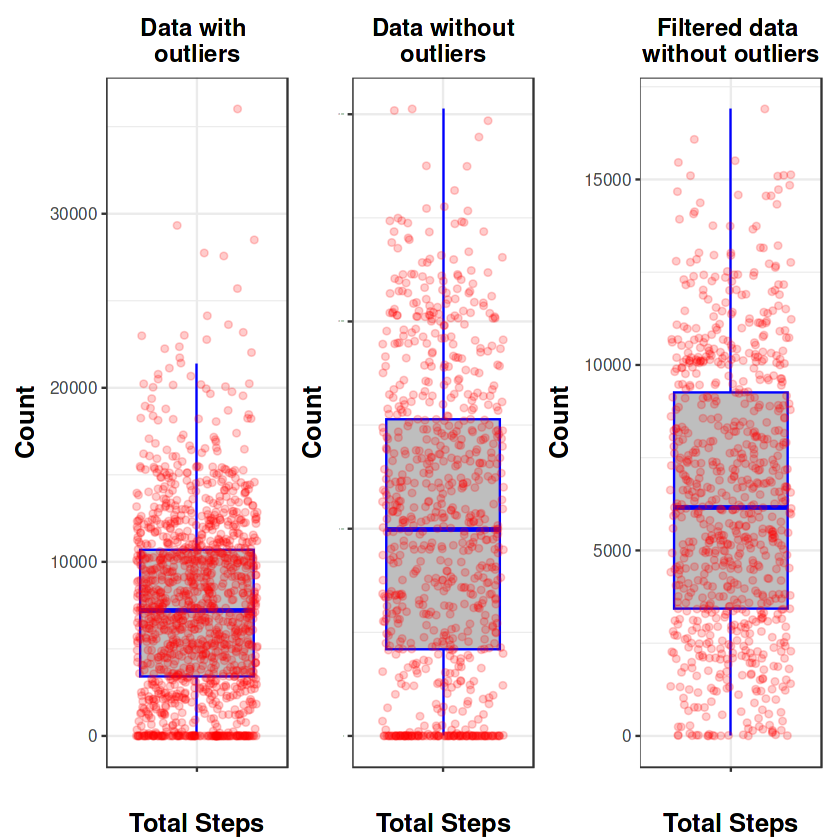

In [11]:
#original data
totalsteps_before <- ggplot(daily_activity, aes(x = " ", y = TotalSteps)) +
  geom_boxplot(color = "blue", fill = "gray",
               outlier.shape = NA) +
geom_jitter(color = "red", alpha = 0.2)+
  theme_bw() +
  labs(title = "Data with \noutliers",
       x = "Total Steps",
       y = "Count") +
theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 10),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5,))

#data with outliers removed
daily_activity_with_zeros <- remove_outlier(daily_activity, c('TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'))

totalsteps_after_with_zeros <- ggplot(daily_activity_with_zeros, aes(x = " ", y = TotalSteps)) +
  geom_boxplot(color = "blue", fill = "gray",
               outlier.shape = NA) +
geom_jitter(color = "red", alpha = 0.2)+
  theme_bw() +
  labs(title = "Data without\noutliers",
       x = "Total Steps",
       y = "Count") +
theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 1),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5,))


#filtered data with outliers removed


totalsteps_after_without_zeros <- ggplot(daily_activity_new, aes(x = " ", y = TotalSteps)) +
  geom_boxplot(color = "blue", fill = "gray",
               outlier.shape = NA) +
geom_jitter(color = "red", alpha = 0.2)+
  theme_bw() +
  labs(title = "Filtered data \nwithout outliers",
       x = "Total Steps",
       y = "Count")+
theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 10),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5,))


(totalsteps_before | totalsteps_after_with_zeros | totalsteps_after_without_zeros)

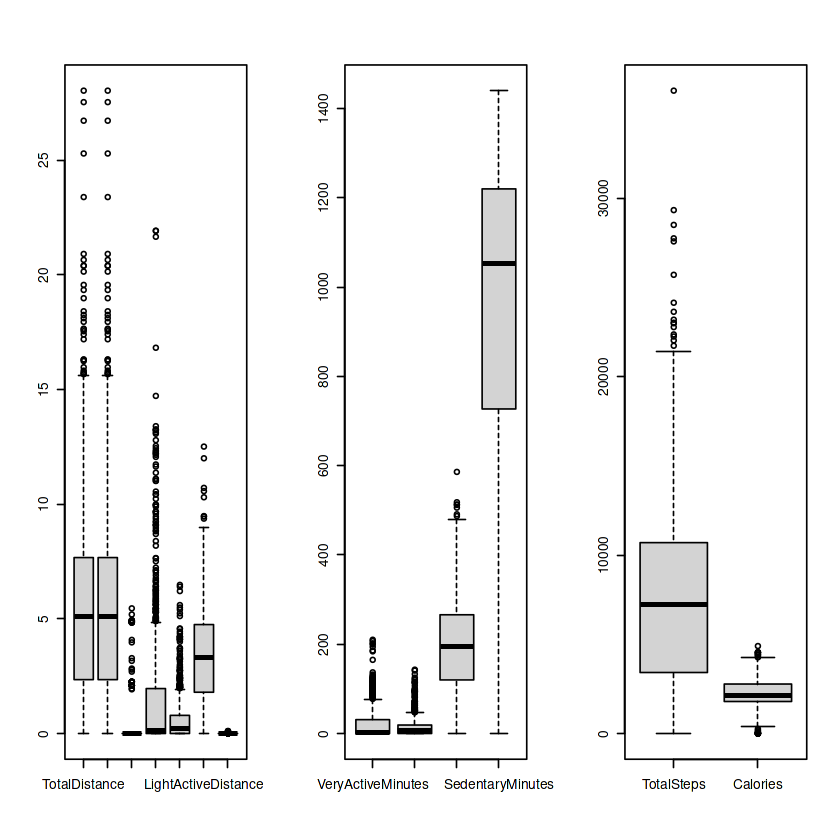

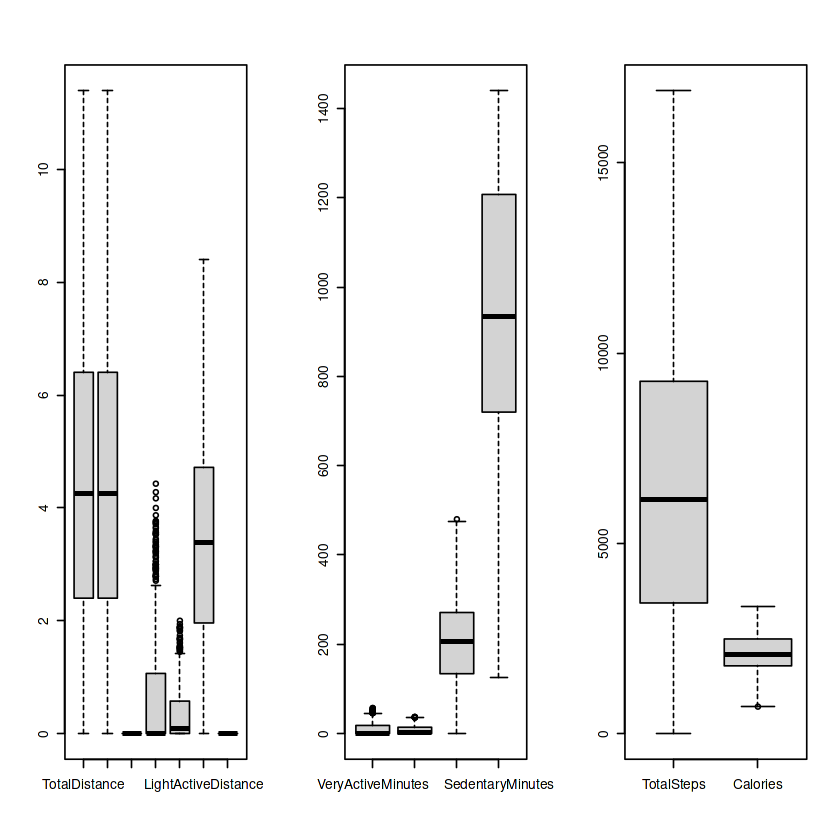

In [12]:
#We can use the boxplot function to check if the remaining quantitative variables in the daily_activity dataset also have outliers to get rid of (just for viewing purposes)
par(mfrow = c(1, 3)) #par() function helps to show plots (that were coded wothout ggplot function)  side-by-side

plot_1 <- boxplot(daily_activity %>% select(4:10))
plot_2 <- boxplot(daily_activity %>% select(11:14))
plot_3 <- boxplot(daily_activity %>% select(3,15))



#let's see how the boxplots for the variables looks after outliers were removed
par(mfrow = c(1, 3)) #par() function helps to show plots (that were coded wothout ggplot function)  side-by-side

plot_11 <- boxplot(daily_activity_new %>% select(4:10))
plot_22 <- boxplot(daily_activity_new %>% select(11:14))
plot_33 <- boxplot(daily_activity_new %>% select(3,15))

### Hourly Steps

Horly steps data include many records that daily_activity_merged dataset misses

In [13]:
hourlySteps_merged_march_april <- read_csv("/kaggle/input/fitabase-data-3-12-16-4-11-2-16/Fitabase Data 3.12.16-4.11-2.16/hourlySteps_merged.csv", show_col_types = FALSE)
hourlySteps_merged_april_may <- read_csv("/kaggle/input/fitabase-data-4-12-16-5-12-16-2/Fitabase Data 4.12.16-5.12-2.16/hourlySteps_merged.csv", show_col_types = FALSE)

hourly_steps_merged <- rbind(hourlySteps_merged_march_april, hourlySteps_merged_april_may) # merged data set

hourly_steps_merged <- hourly_steps_merged %>% 
  separate(col = ActivityHour, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
    mutate(Date = parse_date(Date, '%m/%d/%Y'),
         Time = parse_time(Time, '%I:%M:%S %p')) #change the format of date and time

n_distinct(hourly_steps_merged$Date) # Data collected over a 62-day period
n_distinct(hourly_steps_merged$Id) # Data collected for 35 survey participants
nrow(hourly_steps_merged[duplicated(hourly_steps_merged), ]) #count number of duplicate rows. The result is 175. If we check the dates, we will see that the duplicates result from one day overlap between the data sets

hourlySteps_merged_march_april %>%
  separate(col = ActivityHour, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = as.Date(Date, "%m/%d/%Y")) %>%
    summarise(min= min(Date), max= max(Date)) # from 2016-03-12 to 2016-04-12


hourlySteps_merged_april_may%>%
  separate(col = ActivityHour, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = as.Date(Date, "%m/%d/%Y")) %>%
    summarise(min= min(Date), max= max(Date)) # from 2016-04-12 to 2016-05-12

hourly_steps_merged <- unique(hourly_steps_merged) #merged Hourly Steps data set without duplicates

[1] 62

[1] 35

[1] 175

min,max
<date>,<date>
2016-03-12,2016-04-12


min,max
<date>,<date>
2016-04-12,2016-05-12


Let's plot geom_tile() to see if we have have missing records. We can see that we can exclude two Id (2891001357 and 6391747486)


`summarise()` has grouped output by 'Id'. You can override using the `.groups`
argument.


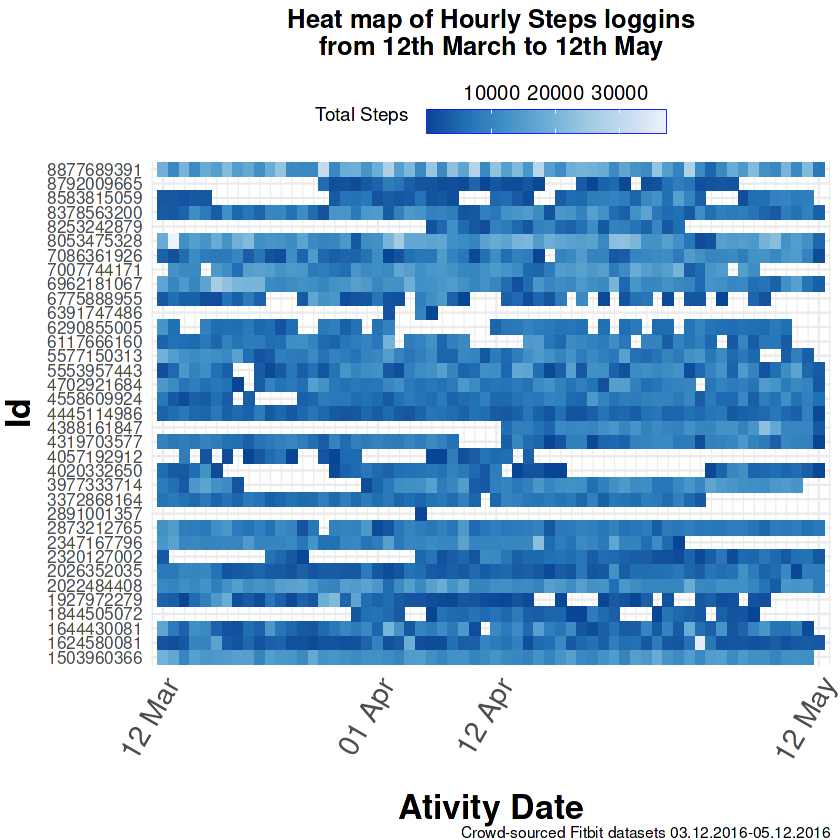

In [14]:

ggplot(data = hourly_steps_merged %>% 
       group_by(Id, Date) %>% 
       filter(StepTotal >0) %>% 
       summarise(Total = sum(StepTotal)), mapping = aes(x = Date,
                                         y = as.character(Id), 
                                         fill = Total)) +
  geom_tile() +
labs(x = "Ativity Date",
     y = "Id",
     title = "Heat map of Hourly Steps loggins\nfrom 12th March to 12th May",
     caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
theme_minimal() +
scale_fill_distiller() +
scale_x_date(date_labels = "%d %b", 
             breaks = as.Date(c('2016-03-12','2016-04-1','2016-04-12', '2016-05-12')), 
             date_minor_breaks = "1 day",
             expand = c(0.01,0))+
theme(axis.text.x = element_text(angle = 60, hjust = 1, vjust = 1, size = 17),
      axis.text.y = element_text(size = 10),
      plot.caption = element_text(vjust = -2, size = 9),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 20, color = "black"),
      axis.title.y = element_text(vjust = 1.5, face = "bold", size = 20, color = "black"),
      legend.position = "top",
      legend.text = element_text(size = 12),
      legend.spacing.x = unit(0.5, 'cm'),
     plot.title = element_text(size = 15, hjust = 0.5, face = "bold")) + 
guides(fill = guide_colorbar(title = "Total Steps",
                               label.position = "top",
                               title.position = "left", title.vjust = 0.3,
                               frame.colour = "blue",
                               barwidth = 10,
                               barheight = 1))

<div class="alert alert-block alert-info">
<b></b> Here we can see that if we merge and filter hourly steps data, we will end up with more TotalSteps records than the merged daily_activity dataset. So when analyzing TotalSteps count and Hourly Steps distribution, we should rely on the hourly_steps_merged dataset to get the better overview.
</div>

Let's create a new dataset, TotalSteps, by grouping and summarizing data in the hourly_steps_merged dataset.

In [15]:
# Let's calculate Total Steps per day from hourly_steps_merged data set to complemet the data from daily_activity_merged data set
TotalSteps_with_otliers <- hourly_steps_merged %>% 
       group_by(Id, Date) %>% 
       filter(StepTotal >0, Id != 2891001357,  Id != 6391747486) %>% 
       summarise(Total = sum(StepTotal))



TotalSteps_without_outliers <- remove_outlier(TotalSteps_with_otliers, c('Total')) #this decreases the number of rows fro 1685 to 1656



`summarise()` has grouped output by 'Id'. You can override using the `.groups`
argument.


[1] "Remove outliers"
# A tibble: 1,655 × 3
# Groups:   Id [33]
           Id Date       Total
        <dbl> <date>     <dbl>
 1 1503960366 2016-03-12 19675
 2 1503960366 2016-03-13 17106
 3 1503960366 2016-03-14 10023
 4 1503960366 2016-03-15 15384
 5 1503960366 2016-03-16 13498
 6 1503960366 2016-03-17 14027
 7 1503960366 2016-03-18 14544
 8 1503960366 2016-03-19 15424
 9 1503960366 2016-03-20 15128
10 1503960366 2016-03-21 10020
# ℹ 1,645 more rows


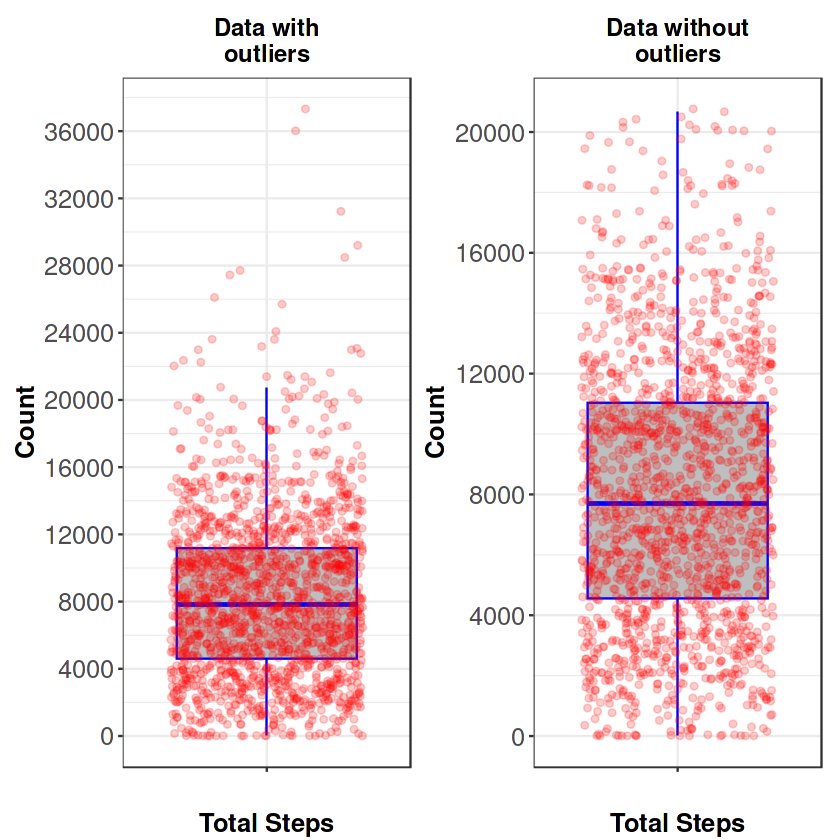

In [16]:
#We can visually evaluate changes in data before and after outliers were removed with geom_boxplot()

plot1 <- ggplot(TotalSteps_with_otliers, aes(x = " ", y = Total)) +
  geom_boxplot(color = "blue", fill = "gray",
               outlier.shape = NA) +
geom_jitter(color = "red", alpha = 0.2)+
scale_y_continuous(breaks = round(seq(0, max(TotalSteps_with_otliers$Total), by = 4000), 1)) +
  theme_bw() +
  labs(title = "Data with\noutliers",
       x = "Total Steps",
       y = "Count") +
theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 15),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5,))

plot2 <- ggplot(TotalSteps_without_outliers, aes(x = " ", y = Total)) +
  geom_boxplot(color = "blue", fill = "gray",
               outlier.shape = NA) +
geom_jitter(color = "red", alpha = 0.2)+
scale_y_continuous(breaks = round(seq(0, max(TotalSteps_with_otliers$Total), by = 4000), 1)) +
  theme_bw() +
  labs(title = "Data without\noutliers",
       x = "Total Steps",
       y = "Count") +
theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 15),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5,))

(plot1| plot2)

### Sleep

We have three separate data sheets for the sleep data:
- minuteSleep_merged.csv (data for 23 people, from 	2016-03-11	to 2016-04-**12**)
- minuteSleep_merged.csv (data for 24 people, from 	2016-04-**11**	to 2016-05-12)
- sleepDay_merged.csv    (data for 23 people, from 	2016-03-11	to 2016-04-**12**, here is an overlap for 2016-04-12)

In [17]:
#transforming sleep data from March to April
sleep_march_april <- read_csv("/kaggle/input/fitabase-data-3-12-16-4-11-2-16/Fitabase Data 3.12.16-4.11-2.16/minuteSleep_merged.csv", show_col_types = FALSE)

sleep_march_april_new <- sleep_march_april %>% 
  mutate(new_date = parse_date_time(date, '%m/%d/%Y %I:%M:%S %p')) %>% 
  separate(col = date, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = as.Date(Date, "%m/%d/%Y"))

sleep_march_april_new <- unique(sleep_march_april_new)

#summary
sleep_march_april_new  %>%
    summarize(number_of_participants = n_distinct(Id),
             from = min(Date),
             to = max(Date),
             n_of_rows = nrow(sleep_march_april_new),
             n_of_duplicates = nrow(sleep_march_april_new[duplicated(sleep_march_april_new), ]))

number_of_participants,from,to,n_of_rows,n_of_duplicates
<int>,<date>,<date>,<int>,<int>
23,2016-03-11,2016-04-12,198034,0


In [18]:
#transforming sleep data from April to May
sleep_april_may <- read_csv("/kaggle/input/fitabase-data-4-12-16-5-12-16-2/Fitabase Data 4.12.16-5.12-2.16/minuteSleep_merged.csv", show_col_types = FALSE)

sleep_april_may_new <- sleep_april_may %>% 
  mutate(new_date = parse_date_time(date, '%m/%d/%Y %I:%M:%S %p')) %>% 
  separate(col = date, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = as.Date(Date, "%m/%d/%Y"))

sleep_april_may_new <- unique(sleep_april_may_new)

#summary
sleep_april_may_new  %>%
    summarize(number_of_participants = n_distinct(Id),
             from = min(Date),
             to = max(Date),
             n_of_rows = nrow(sleep_april_may_new),
             n_of_duplicates = nrow(sleep_april_may_new[duplicated(sleep_april_may_new), ]))

number_of_participants,from,to,n_of_rows,n_of_duplicates
<int>,<date>,<date>,<int>,<int>
24,2016-04-11,2016-05-12,187978,0


In [19]:
#merging sleep data with rbind
sleep_merged <- rbind(sleep_march_april_new, sleep_april_may_new)
sleep <- unique(sleep_merged)
str(sleep)

# merged sleep data summary
sleep %>%
    summarize(number_of_participants = n_distinct(Id),
              from = min(Date),
              to = max(Date),
              n_of_rows = nrow(sleep_merged),
              n_of_duplicates = nrow(sleep[duplicated(sleep), ])) # because of 1 day overlap and not because of the duplicates

tibble [382,780 × 6] (S3: tbl_df/tbl/data.frame)
 $ Id      : num [1:382780] 1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ Date    : Date[1:382780], format: "2016-03-13" "2016-03-13" ...
 $ Time    : chr [1:382780] "2:39:30 AM" "2:40:30 AM" "2:41:30 AM" "2:42:30 AM" ...
 $ value   : num [1:382780] 1 1 1 1 1 1 2 2 1 1 ...
 $ logId   : num [1:382780] 1.11e+10 1.11e+10 1.11e+10 1.11e+10 1.11e+10 ...
 $ new_date: POSIXct[1:382780], format: "2016-03-13 02:39:30" "2016-03-13 02:40:30" ...


number_of_participants,from,to,n_of_rows,n_of_duplicates
<int>,<date>,<date>,<int>,<int>
25,2016-03-11,2016-05-12,386012,0


We can check if we have some missing records in the sleep dataset with the **geom_tile()**. From the [Data Dictionary (page 17)](https://www.fitabase.com/media/1930/fitabasedatadictionary102320.pdf) we can see that value  colimn indicates the sleep state(1 = asleep, 2 = restless, 3 = awake)

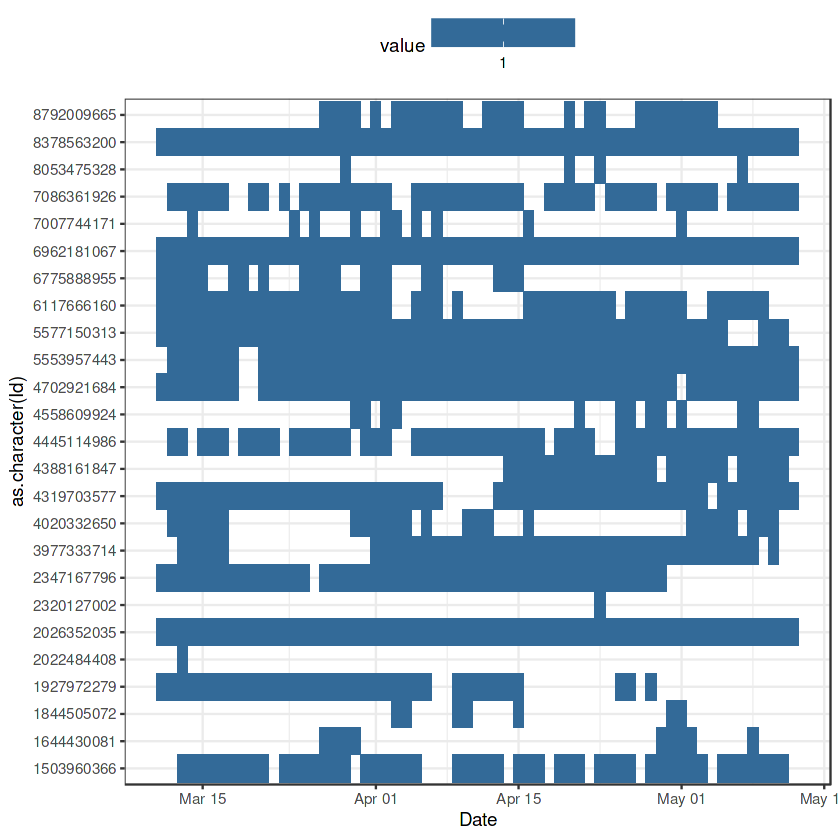

In [20]:
ggplot(data = sleep %>% filter(value == 1), mapping = aes(x = Date,
                                         y = as.character(Id), 
                                         fill = value)) +
  geom_tile() +
  theme_bw() +
  theme(legend.position = "top") 

#the problem is hta twe have more than two records per day for some Ids

From the heatmap, we observe that some participants have only a few records over the entire survey period. Additionally, we notice that the number of sleep records for March is greater than that for daily activity data.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   58.0   361.0   433.0   419.5   490.0   796.0 

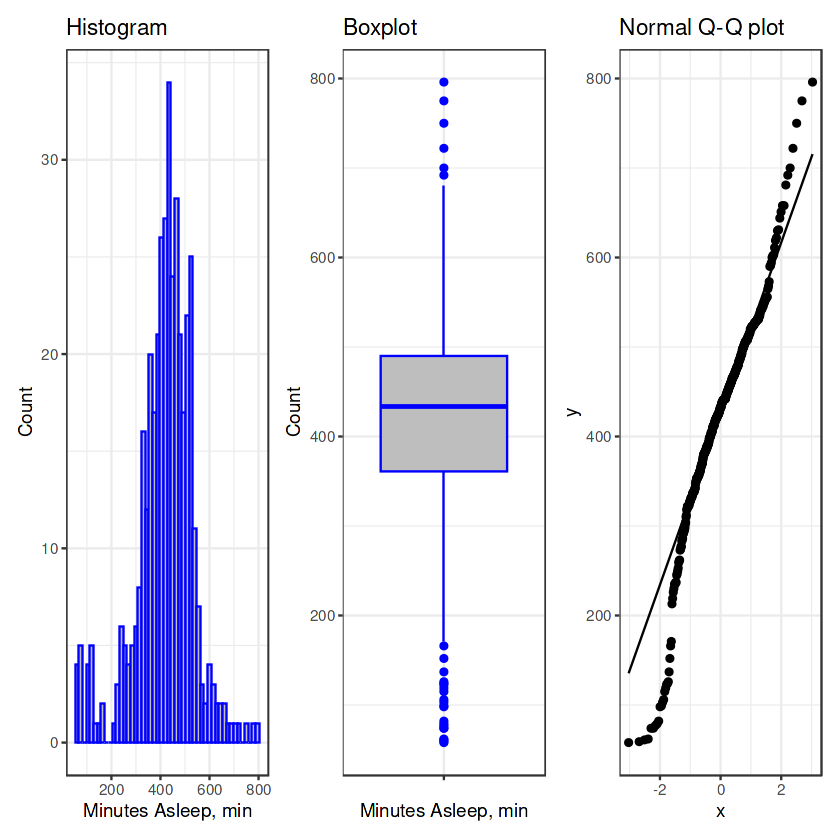

In [21]:
# Let's analyse sleepDay_merged.csv to find an averge time asleep
#Let's first trasnform the data set
sleepDay <- read_csv("/kaggle/input/fitabase-data-4-12-16-5-12-16-2/Fitabase Data 4.12.16-5.12-2.16/sleepDay_merged.csv", show_col_types = FALSE) 

sleep_duration <- sleepDay %>% 
  separate(col = SleepDay, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = parse_date_time(Date, '%m/%d/%Y '))

#Let's summarise TotalMinutesAsleep data before we are searching for the outliers
summary(sleep_duration$TotalMinutesAsleep)

#Let's visualise th distribution of available sleep data
plot1 <- ggplot(sleep_duration, aes(x = TotalMinutesAsleep)) +
  geom_histogram(binwidth = 15, color = "blue", fill = "gray") +
  theme_bw() +
  labs(title = "Histogram",
       x = "Minutes Asleep, min",
       y = "Count")
#we can clearly see outliers with geom_boxplot()
plot2 <- ggplot(sleep_duration, aes(x = " ", y = TotalMinutesAsleep)) +
  geom_boxplot(color = "blue", fill = "gray") +
  theme_bw() +
  labs(title = "Boxplot",
       x = "Minutes Asleep, min",
       y = "Count") 

plot3 <- ggplot(sleep_duration, aes(sample = TotalMinutesAsleep)) + 
    geom_qq() +
    stat_qq_line() +
    theme_bw() +
    labs(title = "Normal Q-Q plot")

(plot1 | plot2 | plot3) # visualise both representations side-by-side with patchwork package

[1] "Remove outliers"
# A tibble: 380 × 6
           Id Date                Time      TotalSleepRecords TotalMinutesAsleep
        <dbl> <dttm>              <chr>                 <dbl>              <dbl>
 1 1503960366 2016-04-12 00:00:00 12:00:00…                 1                327
 2 1503960366 2016-04-13 00:00:00 12:00:00…                 2                384
 3 1503960366 2016-04-15 00:00:00 12:00:00…                 1                412
 4 1503960366 2016-04-16 00:00:00 12:00:00…                 2                340
 5 1503960366 2016-04-19 00:00:00 12:00:00…                 1                304
 6 1503960366 2016-04-20 00:00:00 12:00:00…                 1                360
 7 1503960366 2016-04-21 00:00:00 12:00:00…                 1                325
 8 1503960366 2016-04-23 00:00:00 12:00:00…                 1                361
 9 1503960366 2016-04-24 00:00:00 12:00:00…                 1                430
10 1503960366 2016-04-25 00:00:00 12:00:00…                 1      

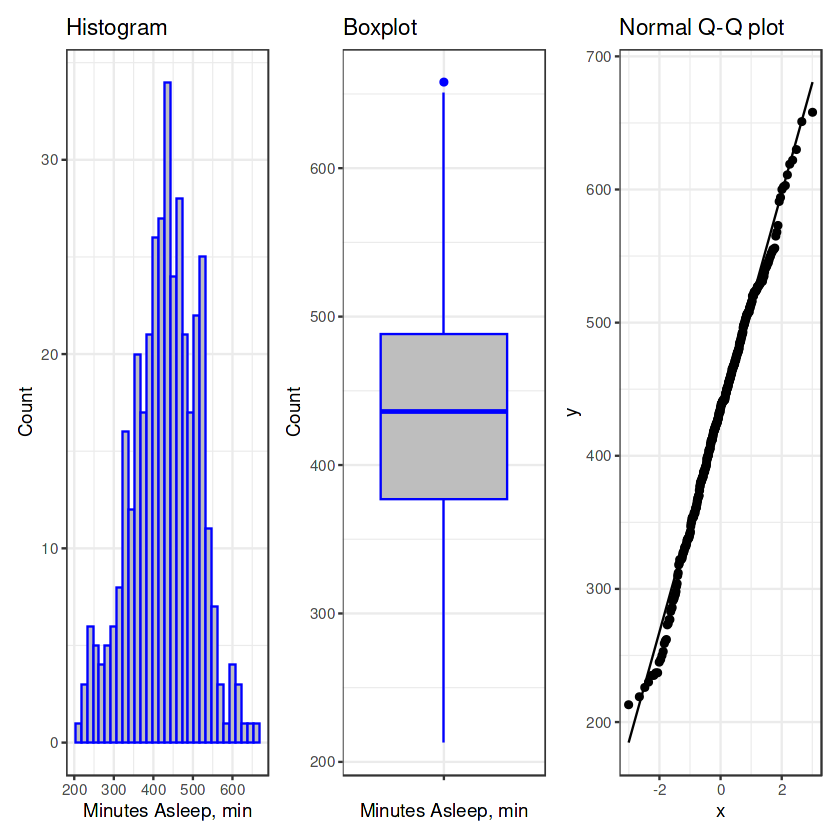

In [22]:
sleep_new <- remove_outlier(sleep_duration, c('TotalMinutesAsleep', 'TotalTimeInBed'))

#Let's visualise th distribution of available sleep data
plot1 <- ggplot(sleep_new, aes(x = TotalMinutesAsleep)) +
  geom_histogram(binwidth = 15, color = "blue", fill = "gray") +
  theme_bw() +
  labs(title = "Histogram",
       x = "Minutes Asleep, min",
       y = "Count")
#we can clearly see outliers with geom_boxplot()
plot2 <- ggplot(sleep_new, aes(x = " ", y = TotalMinutesAsleep)) +
  geom_boxplot(color = "blue", fill = "gray") +
  theme_bw() +
  labs(title = "Boxplot",
       x = "Minutes Asleep, min",
       y = "Count") 

plot3 <- ggplot(sleep_new, aes(sample = TotalMinutesAsleep)) + 
    geom_qq() +
    stat_qq_line() +
    theme_bw() +
    labs(title = "Normal Q-Q plot")

(plot1 | plot2 | plot3)

### Heart rate

We have two datasets with heart information: one for March-April and another for April-May. We can combine them, just as we did for the daily_activity data, and use the geom_tile function to see if the data we have is consistent enough for the analysis

In [23]:
heartrate_march_april <- read_csv("/kaggle/input/fitabase-data-3-12-16-4-11-2-16/Fitabase Data 3.12.16-4.11-2.16/heartrate_seconds_merged.csv", show_col_types = FALSE)
heartrate_april_march <- read_csv("/kaggle/input/fitabase-data-4-12-16-5-12-16-2/Fitabase Data 4.12.16-5.12-2.16/heartrate_seconds_merged.csv", show_col_types = FALSE)
heartrate_merged <- rbind(heartrate_march_april, heartrate_april_march) # merge two data sets into one
str(heartrate_merged) # we can see that Time has a chr type, which should be changed to Date) 

heartrate_merged <- heartrate_merged %>% 
     separate(col = Time, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = parse_date(Date, '%m/%d/%Y'),
         Time = parse_time(Time, '%I:%M:%S %p'))


   # mutate(Time = parse_date_time(Time, '%m/%d/%Y %I:%M:%S %p')) # we change the format of Time
#str(heartrate_merged) # check that we the Time format has changed

heartrate_merged %>%
    summarize(number_of_participants = n_distinct(Id),
             from = min(Date),
             to = max(Date)) # summary 

spc_tbl_ [3,638,339 × 3] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Id   : num [1:3638339] 2.02e+09 2.02e+09 2.02e+09 2.02e+09 2.02e+09 ...
 $ Time : chr [1:3638339] "4/1/2016 7:54:00 AM" "4/1/2016 7:54:05 AM" "4/1/2016 7:54:10 AM" "4/1/2016 7:54:15 AM" ...
 $ Value: num [1:3638339] 93 91 96 98 100 101 104 105 102 106 ...
 - attr(*, "spec")=
  .. cols(
  ..   Id = col_double(),
  ..   Time = col_character(),
  ..   Value = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


number_of_participants,from,to
<int>,<date>,<date>
15,2016-03-29,2016-05-12


We have heart rate information for 15 participants for the time period from March 29th to May 12th. Let's visualise available data wtih geom_tile().

The heart rate merged data has more than 3 000 000 entries, so the processing takes a lot of time, I run the code and just attach the result I want to show

ggplot(data = heartrate_merged, mapping = aes(x = Time,
                                         y = as.character(Id))) +
  geom_tile(color = "blue") +
labs(x = "Ativity Date",
     y = "Id",
     title = "Heat map of Heart Rate loggins\nfrom March 29th to May 12th",
     caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
theme_bw() +
theme(axis.text.x = element_text(vjust = 0.5, size = 17),
      axis.text.y = element_text(size = 10),
      plot.caption = element_text(vjust = -2, size = 9),
      axis.title.x = element_text(vjust = -1.5, face = "bold", size = 20, color = "black"),
      axis.title.y = element_text(vjust = 1.5, face = "bold", size = 20, color = "black"),
      legend.position = "top",
      legend.text = element_text(size = 12),
      legend.spacing.x = unit(0.5, 'cm'),
     plot.title = element_text(size = 15, hjust = 0.5, face = "bold")) 

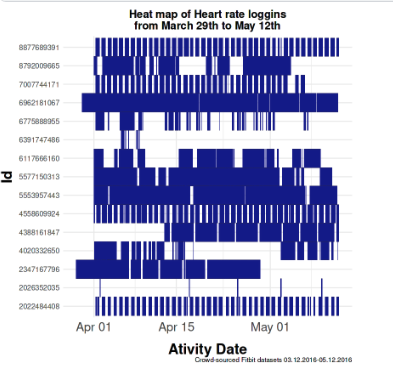

We can check the number of days with heart rate logins to omit some IDs for the analysis. We observe that ID = 2026352035 has data for only 5 days, and ID = 6391747486 has data for only 3 days. I'll exclude them from the analysis

heartrate_merged %>%
   separate(col = Time, into = c("Date", "Time"), sep = " ", extra = "merge") %>%
    group_by(Id) %>%
    summarise(number_of_loggins = n_distinct(Date)) 

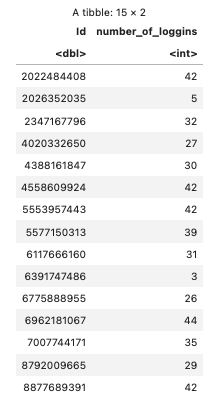

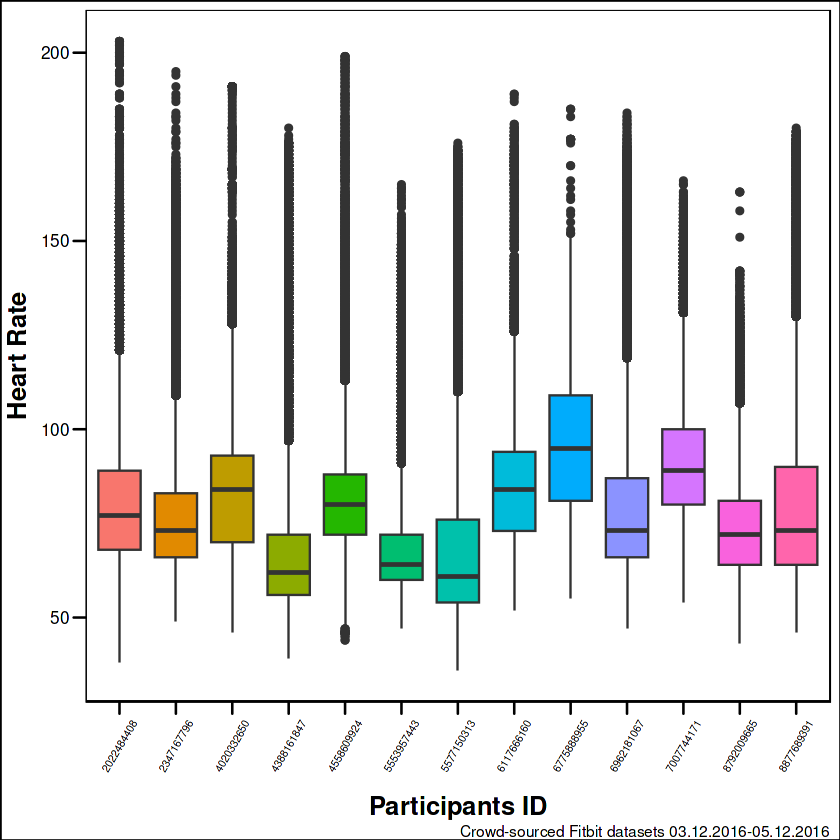

In [24]:
#now we need to check the heartrate data look like. I assume think the variation in the heart rate values looks logical and we don't need to clean the data from an outliers. There is a consistent pattern with high heart rates among all participants (I might be wrong of course. Maybe the data have to be handled differently)

heartrate_merged <- heartrate_merged %>% 
    filter(Id != 2026352035, Id != 6391747486)

ggplot(data = heartrate_merged, mapping = aes(x = as.character(Id),
                                         y = Value,
                                         fill = as.character(Id))) +
  geom_boxplot(show.legend = FALSE) +
  labs(x = "Participants ID",
       y = "Heart Rate",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(angle = 60, vjust = 0.5, size = 6),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8))

### Calories Burned

We can merge two data sets with information about the total number of estimated calories burned during the day.

In [25]:
minuteCalories_March_April <- read_csv("/kaggle/input/fitabase-data-3-12-16-4-11-2-16/Fitabase Data 3.12.16-4.11-2.16/minuteCaloriesNarrow_merged.csv", show_col_types = FALSE)
minuteCalories_April_May <- read_csv("/kaggle/input/fitabase-data-4-12-16-5-12-16-2/Fitabase Data 4.12.16-5.12-2.16/minuteCaloriesNarrow_merged.csv", show_col_types = FALSE)

minute_calories_merged <- rbind(minuteCalories_March_April, minuteCalories_April_May)
minute_calories <- minute_calories_merged %>%  
    separate(col = ActivityMinute, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = parse_date(Date, '%m/%d/%Y'),
         Time = parse_time(Time, '%I:%M:%S %p'))

n_distinct(minute_calories$Date) # Data collected over a 62-day period
n_distinct(minute_calories$Id) # Data collected for 35 survey participants (Id = 2891001357 has records only for 1 day, but since we visualise average calories burned we can leave it as it is. ). Id = 6391747486 has records for 29 days)
nrow(minute_calories[duplicated(minute_calories), ]) # 10500 duplicates

minute_calories <- unique(minute_calories )# duplicates removed

[1] 62

[1] 35

[1] 10500

### METs

All MET values exported from Fitabase are multiplied by 10. !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [26]:
minuteMETs_March_April <- read_csv("/kaggle/input/fitabase-data-3-12-16-4-11-2-16/Fitabase Data 3.12.16-4.11-2.16/minuteMETsNarrow_merged.csv", show_col_types = FALSE)
minuteMETs_April_May <- read_csv("/kaggle/input/fitabase-data-4-12-16-5-12-16-2/Fitabase Data 4.12.16-5.12-2.16/minuteMETsNarrow_merged.csv", show_col_types = FALSE)

minuteMETs_merged <- rbind(minuteMETs_March_April, minuteMETs_April_May)
minuteMETs <- minuteMETs_merged %>%  
    separate(col = ActivityMinute, into = c("Date", "Time"), sep = " ", extra = "merge") %>% 
  mutate(Date = parse_date(Date, '%m/%d/%Y'),
         Time = parse_time(Time, '%I:%M:%S %p'))

n_distinct(minuteMETs$Date) # Data collected over a 62-day period
n_distinct(minuteMETs$Id) # Data collected for 35 survey participants (Id = 2891001357 has records only for 1 day, Id = 6391747486 for 29 days)
nrow(minuteMETs[duplicated(minuteMETs), ]) # 10500 duplicates

minuteMETs <- unique(minuteMETs)# duplicates removed

[1] 62

[1] 35

[1] 10500

# <ins><font color='violet'>Analysis<font><a class='anchor' id='top'></a><ins>

## <font color='green'> Daily Activity Data <font><a class='anchor' id='top'></a>

Let's analyze the daily_activity data and visualize:

- the average number of steps taken by each participant
- how the distance can be broken down into several activity levels (*Very Active, Light, Moderate, Sedentary, Sleep*)
- the average amount of calories consumed by the participants

### Total Steps

First of all, let's plot a boxplot showing the variation in daily total steps counts for the participants. As we determined earlier with geom_tile() visualization, we have consistent TotalSteps records in the daily_activity_new dataset starting from April 1st. The hourly_steps dataset contains additional records for March. We can merge these datasets to obtain more comprehensive statistics on Total Steps count.



In [28]:
daily_activity_TotalSteps <- daily_activity_new %>%
                                select(Id, ActivityDate, TotalSteps) %>%
                                rename(Date = ActivityDate, Steps = TotalSteps) # Choosing several columns and renaming them to merge with hourly steps. 775 entries

hourly_steps_TotalSteps <- TotalSteps_without_outliers %>%
                                rename(Steps = Total)  # 1655 entries

total_steps <- rbind(daily_activity_TotalSteps, hourly_steps_TotalSteps) # 2430 entries

total_steps <- unique(total_steps) #remove duplicates. 1801 entries remain

average_number_of_steps <-  total_steps %>%
    summarise(from = min(Date), to = max(Date), avg_num_of_steps = mean(Steps), st_dev = sd(Steps))

average_number_of_steps

from,to,avg_num_of_steps,st_dev
<date>,<date>,<dbl>,<dbl>
2016-03-12,2016-05-12,7865.026,4443.316


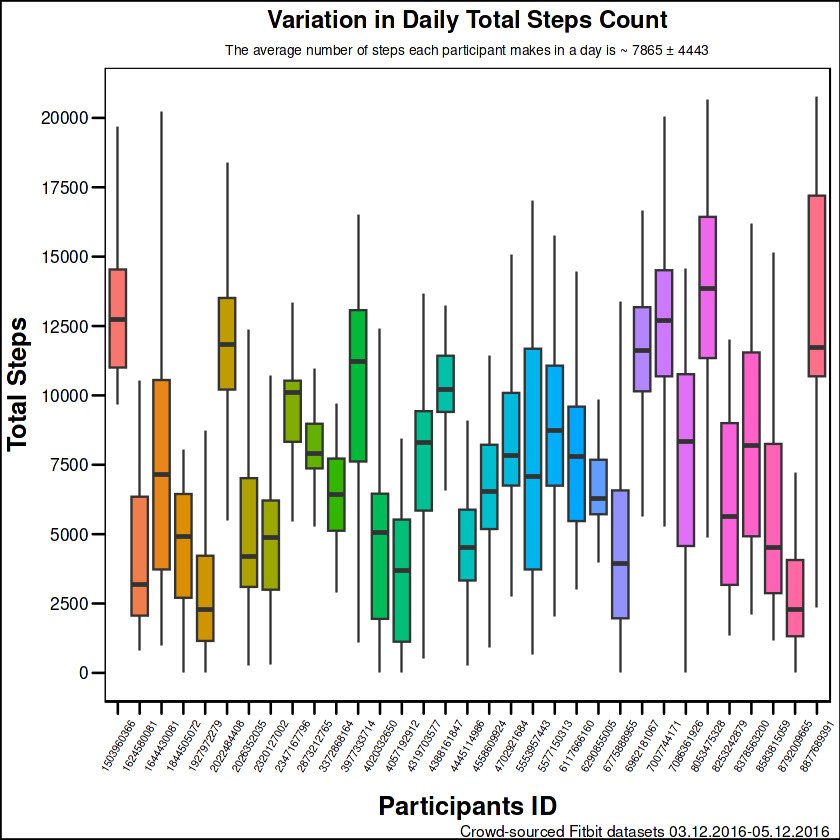

In [29]:
#If we omit zeros and calculate the average number of steps, the value is going to be around 8200 steps per day. In comparison, with filtered data that accounts for outliers, the average number of steps is around 6400.
# The outliers can be hidden to make the plot less busy with the help of the outlier.shape = NA parameter introduced in geom_boxplot().

ggplot(data = total_steps, mapping = aes(x = as.character(Id),
                                         y = Steps,
                                         fill = as.character(Id))) +
  geom_boxplot(outlier.shape = NA, show.legend = FALSE)  +
  scale_y_continuous(breaks = round(seq(0, max(daily_activity$TotalSteps), by = 2500), 1)) +
  labs(x = "Participants ID",
       y = "Total Steps",
       title = "Variation in Daily Total Steps Count",
       subtitle = "The average number of steps each participant makes in a day is ~ 7865 ± 4443",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(angle = 60, vjust = 0.5, size = 6),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8))

<div class="alert alert-success">
The average number of steps the survey participants made in a day is approximately <b>7865 ± 4443<b>.
</div>

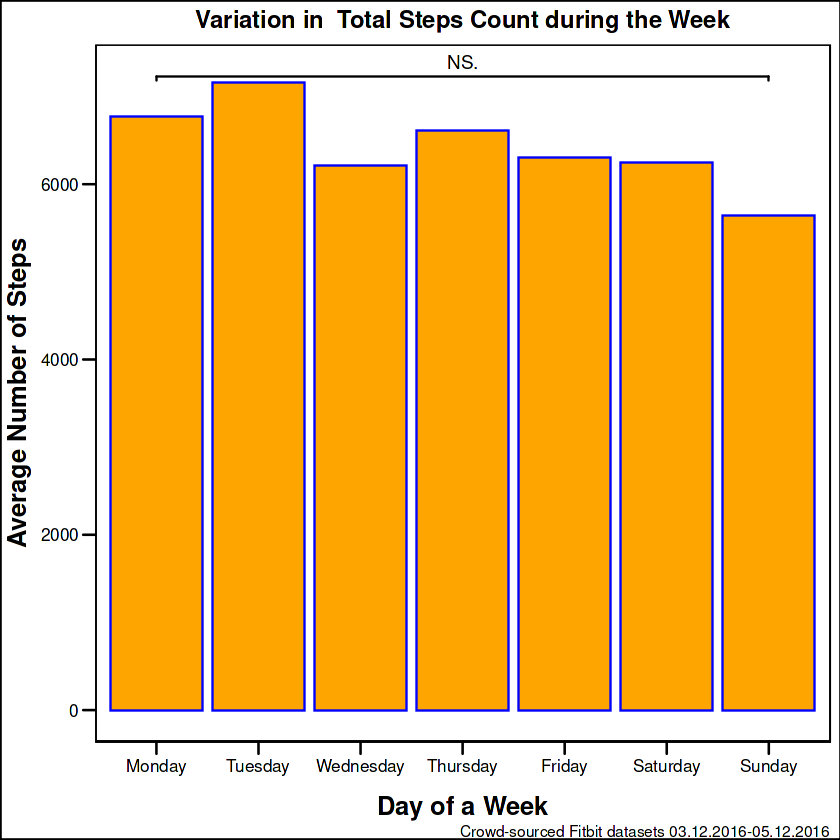

In [30]:
ggplot(data = daily_activity_new %>%
       mutate(weekday = wday(ActivityDate, label = TRUE, abbr = FALSE, week_start = 1)) %>%
    group_by(weekday) %>%
       summarise(avg_num_steps = mean(TotalSteps)), mapping = aes(x = weekday,
                                         y = avg_num_steps)) +
geom_signif(comparisons = list(c("Monday", "Sunday")),
           map_signif_level = TRUE) +
geom_bar(stat="identity", show.legend = FALSE, fill = "orange", color = "blue") +
labs(x = "Day of a Week",
       y = "Average Number of Steps",
       title = "Variation in  Total Steps Count during the Week",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8))


<div class="alert alert-success">
We can assume that the average number of steps decreases toward the end of the week, but the changes are not significant.
</div>

### Hourly Steps

We can analyse hourlySteps_merged.csv to show how many steps participants made on average during the day.

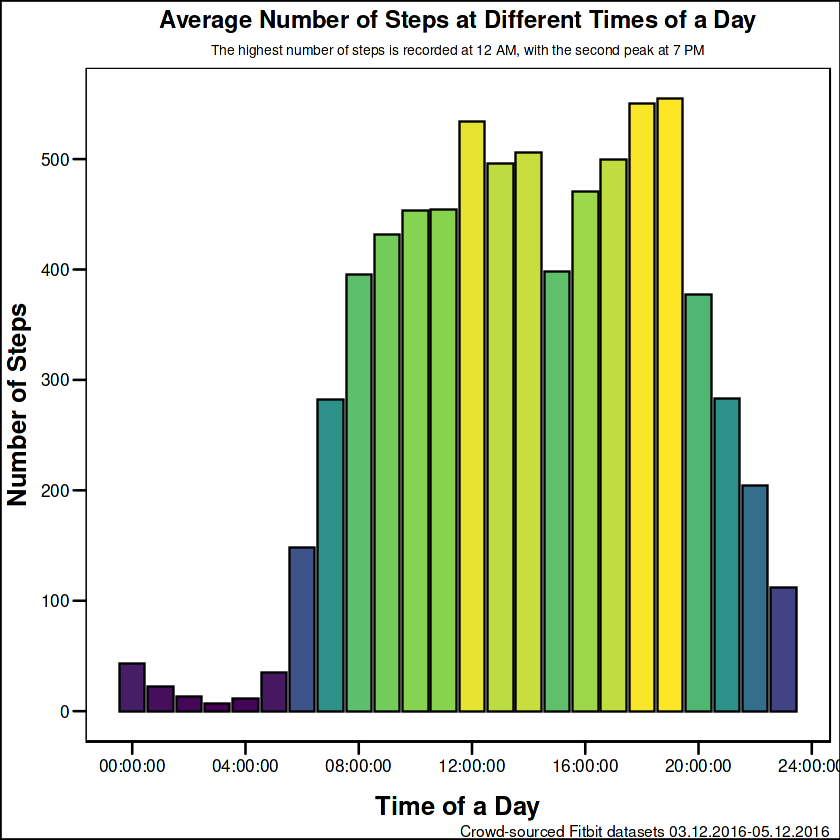

In [31]:
ggplot(hourly_steps_merged %>% 
         group_by(Time) %>% 
         summarise(mean_steps = mean(StepTotal)), aes(x = Time, 
                                                      y = mean_steps,
                                                     fill = mean_steps)) +
  geom_bar(stat = "identity", show.legend = FALSE, color = "black") +
scale_fill_viridis_c() +
  scale_y_continuous(breaks = round(seq(0, max(hourly_steps_merged$StepTotal), by = 100), 1)) +
  labs(x = "Time of a Day",
       y = "Number of Steps",
       title = "Average Number of Steps at Different Times of a Day",
       subtitle = "The highest number of steps is recorded at 12 AM, with the second peak at 7 PM",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8))


<div class="alert alert-success">
The highest number of steps is recorded at <b>12 AM</b>, with the second peak at <b>7 PM</b>.
</div>

### Activity Levels and Sleep

We can also display the time fraction for each activity level:
- VeryActiveMinutes
- FairlyActiveMinutes 
- LightlyActiveMinutes 
- SedentaryMinutes
- Sleep

In [32]:
# first of all, lets summarize available data 
activity_minutes_summary <-  daily_activity_new %>% 
  select(Id, VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes, SedentaryMinutes) %>% 
summarise(mean_VeryActiveMinutes = mean(VeryActiveMinutes),
          mean_FairlyActiveMinutes = mean(FairlyActiveMinutes),
          mean_LightlyActiveMinutes = mean(LightlyActiveMinutes),
          average_sedentary_minutes = mean(SedentaryMinutes),
         total = mean_VeryActiveMinutes + mean_FairlyActiveMinutes + mean_LightlyActiveMinutes + average_sedentary_minutes)

activity_minutes_summary

mean_VeryActiveMinutes,mean_FairlyActiveMinutes,mean_LightlyActiveMinutes,average_sedentary_minutes,total
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9.864516,8.005161,201.4387,952.3884,1171.697


If we summarize activity data, we find out that the sum of VeryActive, FairlyActive, LightlyActive, and Sedentary minutes for some Id's **does not** yield 24 hours (1440 minutes) in total. The assumption is that sedetary minutes include sleep data for some Id's and for some they don't. To find a sleep fraction of a day dedicated to sleep, we can analyse sleep data. 

mean_activity,mean_SleepAndSedentary
<dbl>,<dbl>
3.65514,20.34486


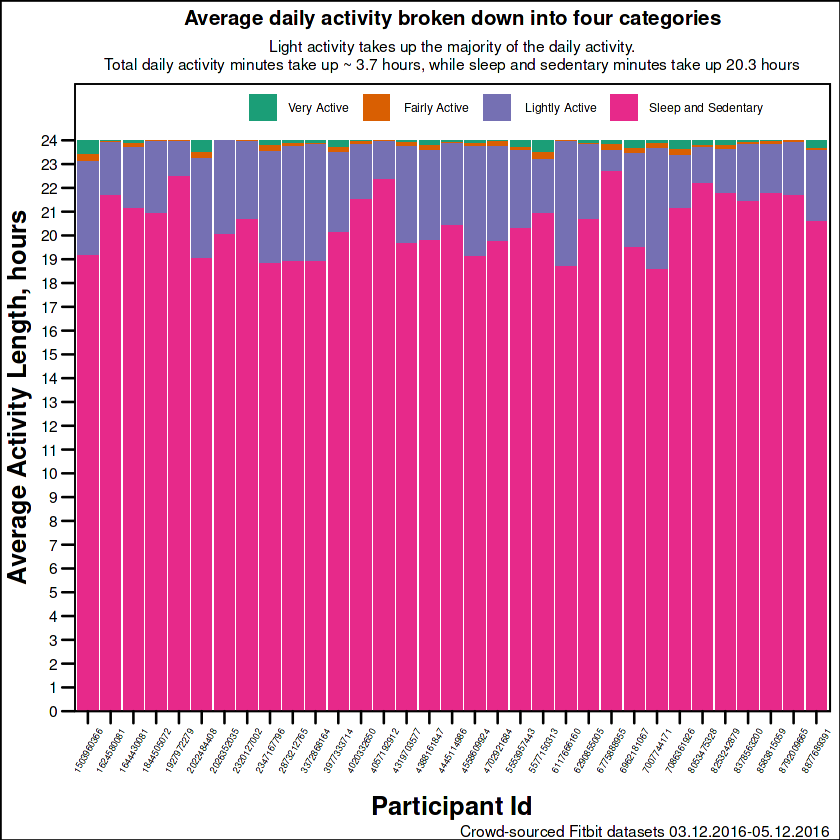

In [33]:
activity_minutes <- daily_activity_new %>% 
  select(Id, VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes, SedentaryMinutes) %>%
  mutate(SleepAndSedentary = 24*60 - (VeryActiveMinutes + FairlyActiveMinutes + LightlyActiveMinutes)) # since sedentary data include sleep data for some Id's lets calculate the total minutes for both of them

activity_minutes %>%
    summarise(mean_activity = mean(VeryActiveMinutes + FairlyActiveMinutes + LightlyActiveMinutes)/60,
             mean_SleepAndSedentary = mean(SleepAndSedentary)/60)

activity_minutes_mean <- activity_minutes %>% 
  group_by(Id) %>% 
  summarise(mean_VeryActiveMinutes = mean(VeryActiveMinutes), 
            mean_FairlyActiveMinutes = mean(FairlyActiveMinutes), 
            mean_LightlyActiveMinutes = mean(LightlyActiveMinutes),
           mean_SleepAndSedentary = mean(SleepAndSedentary)) # summarize and group the data for each Id

activity_minutes_mean_melt <- melt(activity_minutes_mean, id.vars = "Id" ) #transform the data to plot stacked bar chart

ggplot(activity_minutes_mean_melt, aes(x = as.character(Id), y = value/60, fill = variable)) + 
  geom_bar(stat = "identity", show.legend = T) +
  labs(x = "Participant Id",
       y = "Average Activity Length, hours",
       title = "Average daily activity broken down into four categories",
       subtitle = "Light activity takes up the majority of the daily activity.\nTotal daily activity minutes take up ~ 3.7 hours, while sleep and sedentary minutes take up 20.3 hours",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  scale_fill_brewer(palette = "Dark2", labels=c("Very Active","Fairly Active", "Lightly Active", "Sleep and Sedentary"))  +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1)), breaks = round(seq(0, 24, by = 1))) +
  theme_base() +
  theme(axis.text.x = element_text(angle = 60, vjust = 0.5, size = 5),
        axis.text.y = element_text(size = 9),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 12, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9),
        plot.subtitle = element_text(size = 9, hjust = 0.5),
        legend.position = c(0.2,1),
        legend.justification = c(0,1),
        legend.text = element_text(size = 7, hjust = 1.2),
        legend.title = element_blank(),
        legend.background = element_blank(),
        legend.direction = "horizontal") 

<div class="alert alert-success">
    Light activity takes up the majority of the daily activity.Total daily activity minutes take up ~ <b>3.7 hours</b>, while sleep and sedentary minutes take up <b>20.3 hours</b>.
</div>

## <font color='green'> Sleep Data <font><a class='anchor' id='top'></a>

We can calculte the average sleep length

time_asleep
<dbl>
7.16386


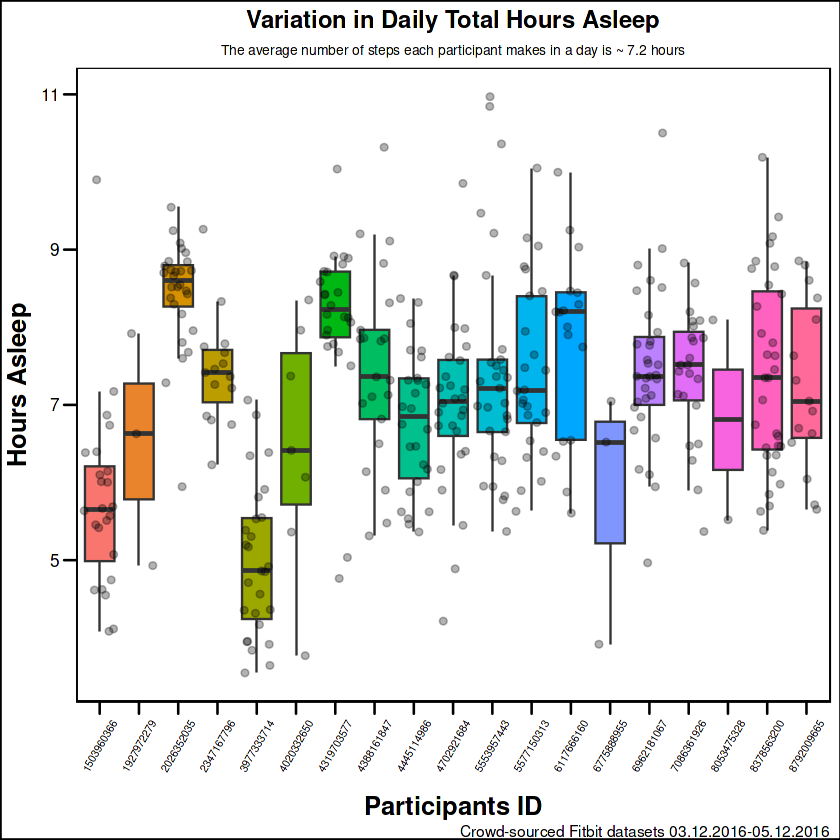

In [34]:
#let's just for now analyse the average sleep length. We can use data from April to May from sleepDay_merged.csv. We dont't have all records available for all Ids. 
sleep_new %>%
    summarise(time_asleep = mean(TotalMinutesAsleep)/60)

ggplot(data = sleep_new, mapping = aes(x = as.character(Id),
                                     y = TotalMinutesAsleep/60,
                                     fill = as.character(Id))) +
geom_boxplot(show.legend = FALSE,
               outlier.shape = NA) +
geom_jitter(show.legend = FALSE, alpha = 0.3) +
  labs(x = "Participants ID",
       y = "Hours Asleep",
       title = "Variation in Daily Total Hours Asleep",
       subtitle = "The average number of steps each participant makes in a day is ~ 7.2 hours",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(angle = 60, vjust = 0.5, size = 6),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8))


### Types of Daily Activity

Let's analyze the daily_activity,csv and visualize whta part of a day is being taking by activity and sleep  with a pie chart using plotly package

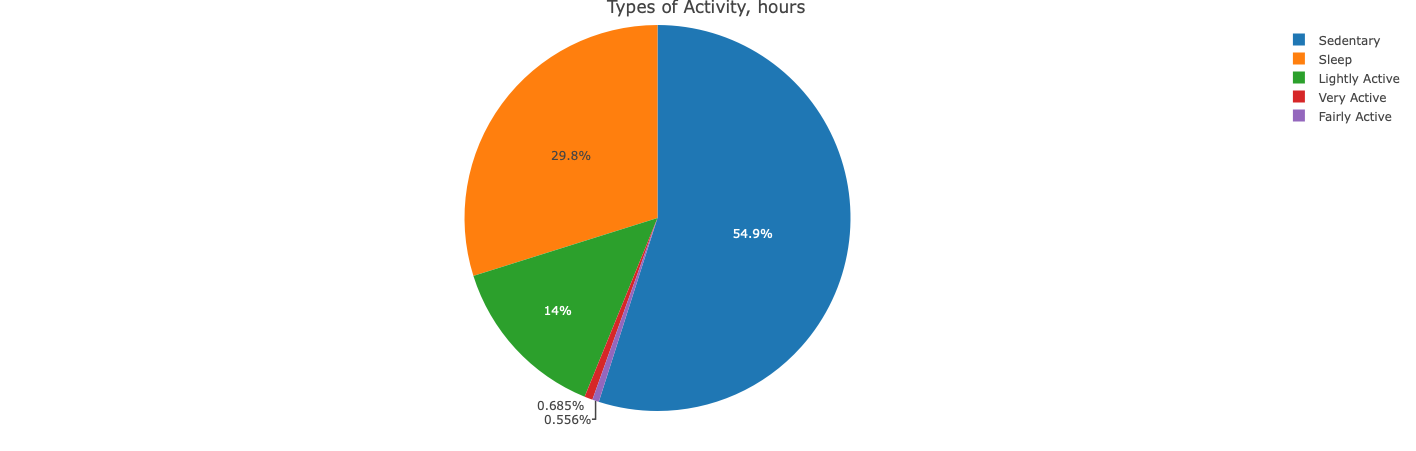

In [35]:
activity_minutes_values <- c(0.1644086, 0.1334194, 3.357312, (24 - (0.1644086 + 0.1334194 + 3.357312 + 7.16386)), 7.16386) #numebers are taken from "Activity Levels and Sleep"
activity_minutes_labels <- c("Very Active", "Fairly Active", "Lightly Active", "Sedentary", "Sleep" )
activity_minutes_pie <- data.frame(activity_minutes_labels, activity_minutes_values)
fig <- plot_ly(activity_minutes_pie, labels = ~activity_minutes_labels, values = ~activity_minutes_values, type = 'pie')
fig <- fig %>% layout(title = 'Types of Activity, hours')
fig

<div class="alert alert-success">
On average, sleep takes up <b>29.8%</b> of a day. Sedentary time occupies <b>54.9%</b>. Light Activity prevails over higher activity levels and constitutes <b>14%</b> of a day.
</div>

### Calories

We can visualize the variation in daily calories consumed among the participants with a boxplot, just like we did for the variation of total steps above.

average_calories,sd_average_calories
<dbl>,<dbl>
2115.431,519.4459


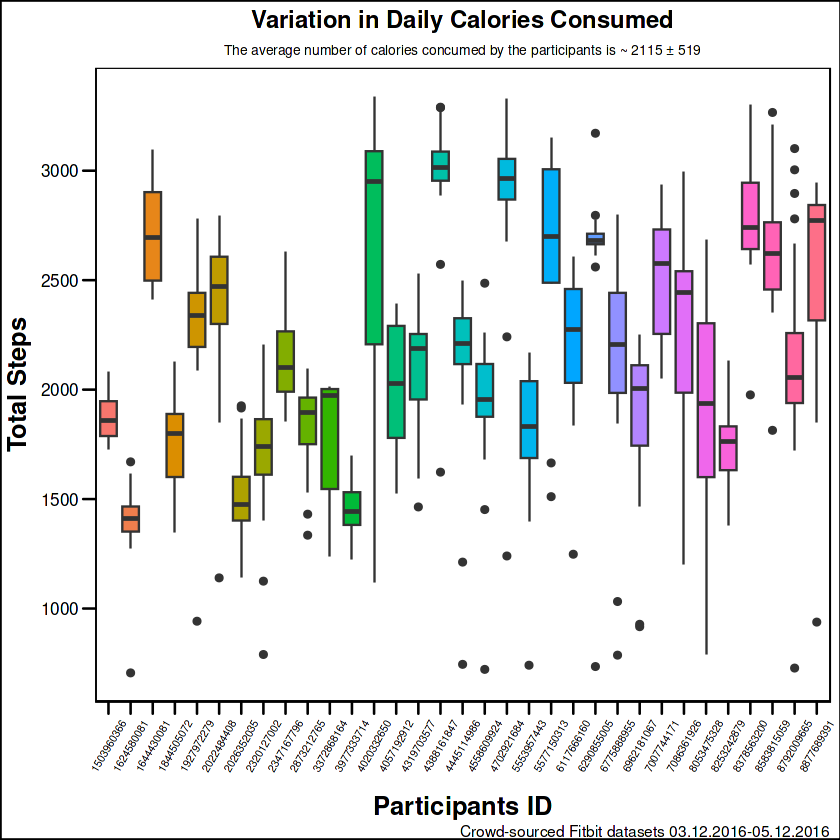

In [36]:
daily_activity_new %>%
    summarise(average_calories = mean(Calories),
         sd_average_calories = sd(Calories))

ggplot(daily_activity_new, aes(x = as.character(Id),
                          y = Calories,
                               fill = as.character(Id))) +
  geom_boxplot(show.legend = FALSE)  +
  labs(x = "Participants ID",
       y = "Total Steps",
       title = "Variation in Daily Calories Consumed",
       subtitle = "The average number of calories concumed by the participants is ~ 2115 ± 519",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(angle = 60, vjust = 0.5, size = 6),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8))

<div class="alert alert-success">
The average number of calories concumed by the participants is ~ <b>2115 ± 519</b>.
</div>

We can visualize the number of calories burned by participants during a day, similar to how we did for hourly steps above.

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


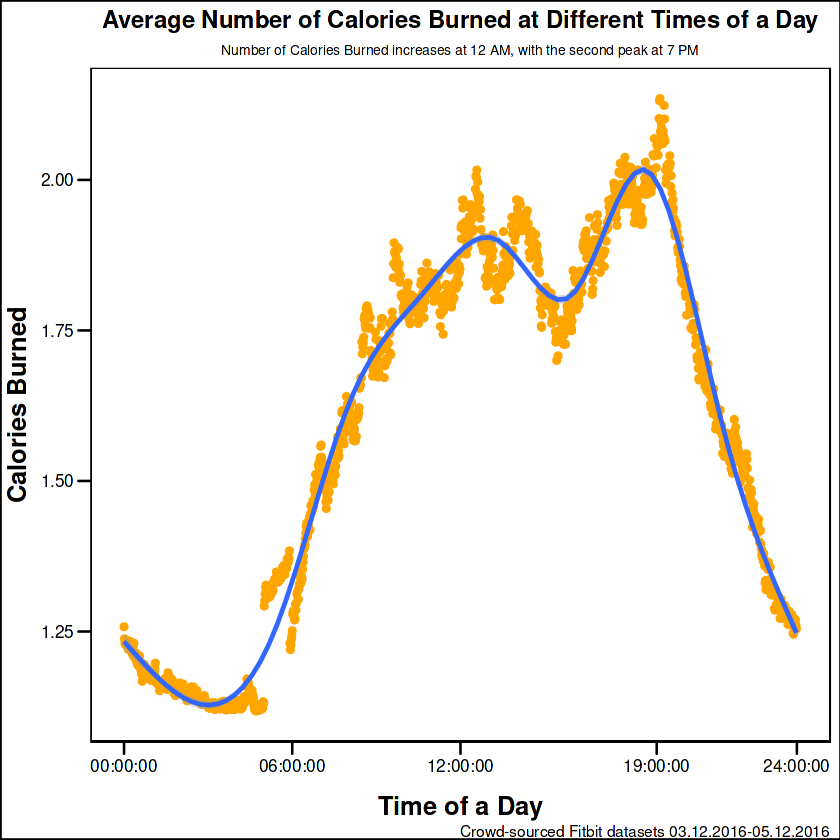

In [41]:

ggplot(minute_calories %>%
         group_by(Time) %>% 
         summarise(mean = mean(Calories)), aes(x = Time, y = mean)) +
  geom_point(color = "orange") +
  geom_smooth() + 

labs(x = "Time of a Day",
       y = "Calories Burned",
       title = "Average Number of Calories Burned at Different Times of a Day",
       subtitle = "Number of Calories Burned increases at 12 AM, with the second peak at 7 PM",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8)) +
scale_x_time(breaks = c(hms("00:00:00"),hms("6:00:00"), hms("12:00:00"), hms("19:00:00"), hms("24:00:00")))  


<div class="alert alert-success">
Number of Calories Burned increases at 12 AM, with the second peak at 7 PM, thus repeating the pattern of Hourly Steps.
</div>

### METs

METs values increase at 12 AM, with the second peak at 7 PM. The average MET varies between 1 and 1.75. Any type of physical activity with a MET value < 3 is considered as light-intensity activity, such as sitting at the desk or walking slowly.

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


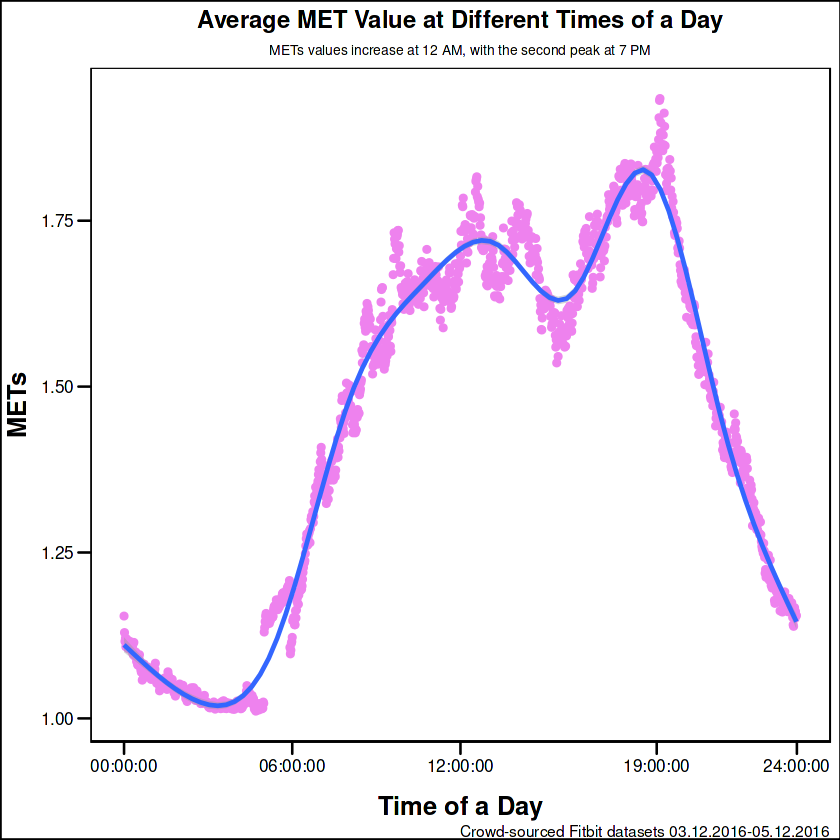

In [51]:
ggplot(minuteMETs %>%
         group_by(Time) %>% 
         summarise(mean = mean(METs)), aes(x = Time, y = mean/10)) +
  geom_point(color = "violet") +
  geom_smooth() +
  labs(x = "Time of a Day",
       y = "METs",
       title = "Average MET Value at Different Times of a Day",
       subtitle = "METs values increase at 12 AM, with the second peak at 7 PM",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(vjust = 0.5, size = 10),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8)) +
scale_x_time(breaks = c(hms("00:00:00"),hms("6:00:00"), hms("12:00:00"), hms("19:00:00"), hms("24:00:00")))  

### Heart rate

First of all we can show how the heart rate varies among the syrvey participants. We have data only for 15 of them. Next we can visualise the pattern for the heart rate changes during the day.

In [ ]:
# first of all the genaral overview for all available Ids

ggplot(data = heartrate_merged, mapping = aes(x = as.character(Id),
                                         y = Value,
                                         fill = as.character(Id))) +
  geom_boxplot(show.legend = FALSE) +
  labs(x = "Participants ID",
       y = "Heart Rate",
       title = "Variation in Heart Rate",
       caption = "Crowd-sourced Fitbit datasets 03.12.2016-05.12.2016") +
  theme_base() +
  theme(axis.text.x = element_text(angle = 60, vjust = 0.5, size = 6),
        axis.text.y = element_text(size = 10),
        axis.title.x = element_text(vjust = -1.5, face = "bold", size = 15, color = "black"),
        axis.title.y = element_text(vjust = 1.5, face = "bold", size = 15, color = "black"),
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5,),
        plot.caption = element_text(vjust = -2, size = 9), 
       plot.subtitle = element_text(hjust = 0.5, size = 8))



ggplot(heartrate_merged_new %>%
         group_by(Time) %>% 
         summarise(mean = mean(Value)), aes(x = Time, y = mean)) +
  geom_point() +
  geom_smooth(se = FALSE)